# Tarea 74 - Automobile

Fai unha regresión co dataset Automobile

Trátase de predicir o prezo dun vehículo a partires das características do mesmo. Neste caso vas a ter moitas columnas de entrada categóricas, polo que terás que transformalas.

Os datos os podes descargar de [aquí](https://archive.ics.uci.edu/dataset/10/automobile)

## Imports

In [242]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import random_split
import torch.nn.functional as F
import torch.nn as nn
import joblib

from torch.utils.tensorboard import SummaryWriter

## CUDA

In [243]:
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print('Using device:', device)
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

torch.backends.cuda.matmul.allow_tf32 = True

# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

Using device: cpu


## Procesamiento de datos

In [244]:
dataAuto = pd.read_csv("../data/automobile/imports-85.data", sep=r',', names=['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
    'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size',
    'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'])
dataAuto

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [245]:
dataAuto.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

### Escalar

In [246]:
class StandardScaler:

    def __init__(self, mean=None, std=None, epsilon=1e-7):
        """Standard Scaler.
        The class can be used to normalize PyTorch Tensors using native functions. The module does not expect the
        tensors to be of any specific shape; as long as the features are the last dimension in the tensor, the module
        will work fine.
        :param mean: The mean of the features. The property will be set after a call to fit.
        :param std: The standard deviation of the features. The property will be set after a call to fit.
        :param epsilon: Used to avoid a Division-By-Zero exception.
        """
        self.mean = mean
        self.std = std
        self.epsilon = epsilon
    def fit(self, values):
        dims = list(range(values.dim() - 1))
        self.mean = torch.mean(values, dim=dims)
        self.std = torch.std(values, dim=dims)
    def transform(self, values):
        return (values - self.mean) / (self.std + self.epsilon)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)

    def __repr__(self):
        return f"mean: {self.mean}, std:{self.std}, epsilon:{self.epsilon}"

In [247]:
dataAuto.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

### Dataset Automobile

In [248]:
class AutomobileDataset(Dataset):
  def __init__(self, src_file, root_dir, transform=None):
    autoDataset = pd.read_csv(src_file, sep=r',', names=['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
    'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size',
    'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'])

    # Trato de datos catgóricos y nulos
    df_procesado = self.tratoLimpiezaNulosCategoricos(autoDataset)

    X = df_procesado.drop(columns=['price'])
    Y = df_procesado[["price"]]

    X_tensor_previo = torch.tensor(X.values, dtype=torch.float32)

    # Scalamos
    self.scaler = StandardScaler()
    XScalada = self.scaler.fit_transform(X_tensor_previo)

    # Convertir a tensores
    x_tensor = XScalada.to(device)
    y_tensor = torch.tensor(Y.values, dtype=torch.float32, device=device)

    self.data = torch.cat((x_tensor, y_tensor), 1)
    
    self.root_dir = root_dir
    self.transform = transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    if torch.is_tensor(idx):
      idx = idx.tolist()

    preds = self.data[idx, :-1] # TODO: aperez: recogeme todas menos la ultima que es el target. Mejor poner asi que valores fijos
                                # por si aumenta las dimensiones con dumies más abajo
    spcs = self.data[idx, -1:] #TODO: aperez: Le quitamos float por que data ya hereda, con otros puede que cambie si no paso los tensors antes a float32
    sample = (preds, spcs)

    if self.transform:
      sample = self.transform(sample)
    return sample
  
  def tratoLimpiezaNulosCategoricos(self, df):
    # Trato de '?' y nulos (lo que ya tenías)
    df.replace("?", np.nan, inplace=True)
    df.dropna(subset=["price"], axis=0, inplace=True)

    # Convertir TODO lo que sabemos que es numérico a float
    # Esto asegura que las columnas originales dejen de ser 'object'
    cols_num = ["normalized-losses", "bore", "stroke", "horsepower", 
                "peak-rpm", "wheel-base", "length", "width", "height", 
                "curb-weight", "engine-size", "compression-ratio", 
                "city-mpg", "highway-mpg", "price"]
    
    for col in cols_num:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Imputación de nulos
    for col in ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm"]:
        df[col] = df[col].fillna(df[col].mean())

    df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

    # Mapeo y Dummies (lo que ya tenías)
    dic_puertas = {"four": 4, "two": 2}
    dic_cilindros = {"two": 2, "three": 3, "four": 4, "five": 5, "six": 6, "eight": 8, "twelve": 12}
    df['num-of-doors'] = df['num-of-doors'].map(dic_puertas)
    df['num-of-cylinders'] = df['num-of-cylinders'].map(dic_cilindros)

    cols_nominales = ['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels', 
                      'engine-location', 'engine-type', 'fuel-system']
    df = pd.get_dummies(df, columns=cols_nominales)

    # --- AQUÍ ESTÁ EL TRUCO FINAL ---
    # Forzamos que ABSOLUTAMENTE TODO el dataframe sea float
    # Esto convierte los True/False de los dummies en 1.0/0.0
    df = df.astype(float)
    
    # Asegurarnos de que price quede al final
    price_col = df.pop('price')
    df['price'] = price_col
  
    return df  

### Cargar dataset Autmobile

In [249]:
dataset = AutomobileDataset("../data/automobile/imports-85.data", root_dir=None)
display(dataset[0])
print(dataset.data.shape)

(tensor([ 1.7208,  0.0000, -1.1535, -1.6809, -0.4383, -0.8513, -2.0290, -0.0148,
         -0.3428,  0.0752,  0.5196, -1.8254, -0.2907,  0.2035, -0.2459, -0.6506,
         -0.5409,  8.1038, -0.1750, -0.2031, -0.1228, -0.2160, -0.2623, -0.1000,
         -0.1228, -0.3032, -0.2031, -0.0705, -0.2623, -0.3128, -0.2400, -0.1895,
         -0.1421, -0.1000, -0.1750, -0.2513, -0.4341, -0.2513, -0.2400, -0.3316,
          0.3316,  0.4659, -0.4659,  5.6867, -0.2031, -0.7133, -0.9350, -0.3760,
         -0.2031, -1.1894,  1.2929,  0.1228, -0.1228,  3.9587, -0.2513, -1.6051,
         -0.2833, -0.2623, -0.1421, -0.2400, -0.6818, -0.1228, -0.3316, -0.0705,
          1.0858, -0.2160, -0.0705]),
 tensor([13495.]))

torch.Size([201, 68])


## División en Train y Test

In [ ]:
lonxitudeDataset = len(dataset)
tamTrain =int(lonxitudeDataset*0.8)
tamVal = lonxitudeDataset - tamTrain

train_set, val_set = random_split(dataset, [tamTrain, tamVal]) # TODO: aperez: Faltaba esta linea para futuros proyectos

print(f"Tam dataset: {lonxitudeDataset} train: {tamTrain} tamVal: {tamVal}")
train_ldr = torch.utils.data.DataLoader(train_set, batch_size=2,
    shuffle=True, drop_last=False)

# TODO: aperez: num_workers=2 -> S.O: Linux o macOS, PyTorch puede crear "clones" (forks) del proceso principal muy fácilmente para que carguen los datos en paralelo
#               En Windowns maneja el multiprocesamiento de forma diferente (usa algo llamado spawn). Al intentar crear estos subprocesos dentro de un Notebook, 
#               Windows se lía intentando recargar todo tu código desde cero, y los trabajadores colapsan. Ponemos a 0!!

# validation_loader =torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)
validation_loader =torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=0)   

Tam dataset: 201 train: 160 tamVal: 41


## Creación de Moldelo

In [ ]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.dropout = nn.Dropout(0.1) # Apaga el 10% de las neuronas
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(in_features=64, out_features=1)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        # Aplicamos Dropout justo aquí
        # Esto "apaga" neuronas aleatorias solo durante el entrenamiento
        x = self.dropout(x)

        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x

## Instanciar el Modelo

### Ver Neuronas Salida/Entrada dimensiones
Confirmamos el número después de tratar los datos categóricos con getdumies. Aumento de columnas, propiedades, features..,

In [252]:
# El tensor total tiene forma: [filas, columnas_totales]
total_filas, total_columnas = dataset.data.shape

# Neuronas de Entrada: Todas las columnas menos la última (el precio)
input_dim = total_columnas - 1

# Neuronas de Salida: Solo 1 (queremos predecir el precio)
output_dim = 1

print(f"--- Dimensiones del Modelo ---")
print(f"Entradas (Input Neurons): {input_dim}")
print(f"Salidas (Output Neurons): {output_dim}")
print(f"Total de registros: {total_filas}")

--- Dimensiones del Modelo ---
Entradas (Input Neurons): 67
Salidas (Output Neurons): 1
Total de registros: 201


### Instancia

In [253]:
model = Model(67).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
loss_fn = torch.nn.MSELoss() 
display(model)

Model(
  (layer1): Linear(in_features=67, out_features=64, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
)

### Prueba

In [254]:
entradaProba,dest = next(iter(train_ldr))
print("Entrada:")
display(entradaProba)
print("Desexada:")
display(dest)
saida = model(entradaProba) # esta é a proba de verdade
print("Saída:")
display(saida)
loss_fn(saida, dest.view(-1, 1).float())

Entrada:


tensor([[ 0.1269, -0.5626, -1.1535, -0.9391, -1.2255, -0.8037,  0.1362, -1.2578,
         -0.3428, -0.8635, -1.1218, -0.3383, -0.2907, -0.9473, -0.2459,  0.9062,
          1.0731, -0.1228, -0.1750, -0.2031, -0.1228, -0.2160, -0.2623, -0.1000,
         -0.1228,  3.2817, -0.2031, -0.0705, -0.2623, -0.3128, -0.2400, -0.1895,
         -0.1421, -0.1000, -0.1750, -0.2513, -0.4341, -0.2513, -0.2400, -0.3316,
          0.3316,  0.4659, -0.4659, -0.1750, -0.2031,  1.3950, -0.9350, -0.3760,
         -0.2031,  0.8366, -0.7696,  0.1228, -0.1228, -0.2513, -0.2513,  0.6199,
         -0.2833, -0.2623, -0.1421, -0.2400,  1.4594, -0.1228, -0.3316, -0.0705,
         -0.9164, -0.2160, -0.0705],
        [ 0.9238, -0.8751,  0.8626, -0.2468, -0.2030, -0.1851,  0.7898, -0.5426,
         -0.3428, -0.4303, -0.5249,  0.4528, -0.2907, -0.4924,  0.2769,  0.2835,
          0.4862, -0.1228, -0.1750, -0.2031, -0.1228, -0.2160, -0.2623, -0.1000,
         -0.1228, -0.3032, -0.2031, -0.0705, -0.2623, -0.3128, -0.2400, 

Desexada:


tensor([[6795.],
        [8495.]])

Saída:


tensor([[0.0633],
        [0.1061]], grad_fn=<AddmmBackward0>)

tensor(59167192., grad_fn=<MseLossBackward0>)

## Entrenamiento

In [255]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    # usamos enumerate para saber en que batch imos
    for i, data in enumerate(train_ldr):
        # Every data instance is an input + label pair
        inputs, labels = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()
        # Make predictions for this batch
        outputs = model(inputs)
        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels.view(-1, 1).float())
        loss.backward()
        # Adjust learning weights
        optimizer.step()
        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            running_loss = 0.
    return last_loss

In [256]:
writer = SummaryWriter('runs/experimento_airfoil')

EPOCHS = 500
loss_list = torch.zeros((EPOCHS,))
mae_list  = torch.zeros((EPOCHS,))

for epoch in range(EPOCHS):
    print(f'EPOCH {epoch + 1}:')

    model.train(True)
    avg_loss = train_one_epoch(epoch, writer)
    loss_list[epoch] = avg_loss

    # Esto habilitará la pestaña "Histograms" en TensorBoard
    for name, param in model.named_parameters():
        writer.add_histogram(name, param, epoch + 1)

    # Validación
    model.train(False)
    running_vloss = 0.0
    running_mae = 0.0
    
    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            
            # Ajuste de dimensiones y tipo para regresión
            vlabels_v = vlabels.view(-1, 1).float()
            
            vloss = loss_fn(voutputs, vlabels_v)
            running_vloss += vloss.item()

            # Calculamos el error real (MAE) para TensorBoard
            batch_mae = torch.abs(voutputs - vlabels_v).mean()
            running_mae += batch_mae.item()

    avg_vloss = running_vloss / (i + 1)
    avg_mae = running_mae / (i + 1)
    mae_list[epoch] = avg_mae

    # Enviar datos a Tensorboard
    # Esto creará las gráficas que verás en el navegador
    writer.add_scalars('Loss_Train_vs_Valid', 
                       {'Training': avg_loss, 'Validation': avg_vloss}, 
                       epoch + 1)
    writer.add_scalar('MAE_Validation', avg_mae, epoch + 1)
    
    print(f'LOSS train {avg_loss:.4f} valid {avg_vloss:.4f} | MAE: {avg_mae:.2f}')

# Forzar escritura y cerrar
# Sin esto, TensorBoard puede salir en blanco
writer.flush()
writer.close()
print("Entrenamiento finalizado y datos guardados en TensorBoard.")

EPOCH 1:
  batch 10 loss: 211982939.2
  batch 20 loss: 289894519.2
  batch 30 loss: 192078502.4
  batch 40 loss: 202052129.2
  batch 50 loss: 122342870.4
  batch 60 loss: 237969653.2
  batch 70 loss: 409811608.8
  batch 80 loss: 305504952.0
LOSS train 305504952.0000 valid 196905913.0909 | MAE: 12167.46
EPOCH 2:
  batch 10 loss: 157445487.2
  batch 20 loss: 295451427.2
  batch 30 loss: 299172124.8
  batch 40 loss: 239011108.8
  batch 50 loss: 269877556.0
  batch 60 loss: 235551690.0
  batch 70 loss: 240295881.6
  batch 80 loss: 233995230.4
LOSS train 233995230.4000 valid 196733410.9091 | MAE: 12161.97
EPOCH 3:
  batch 10 loss: 220562230.4
  batch 20 loss: 311262712.4
  batch 30 loss: 201165647.6
  batch 40 loss: 182863874.4
  batch 50 loss: 329212884.8
  batch 60 loss: 309106168.8
  batch 70 loss: 243183771.2
  batch 80 loss: 170104819.6
LOSS train 170104819.6000 valid 196147033.4545 | MAE: 12144.76
EPOCH 4:
  batch 10 loss: 151083308.4
  batch 20 loss: 257169706.4
  batch 30 loss: 5230

## Gráfica de "Real vs. Predicciones"

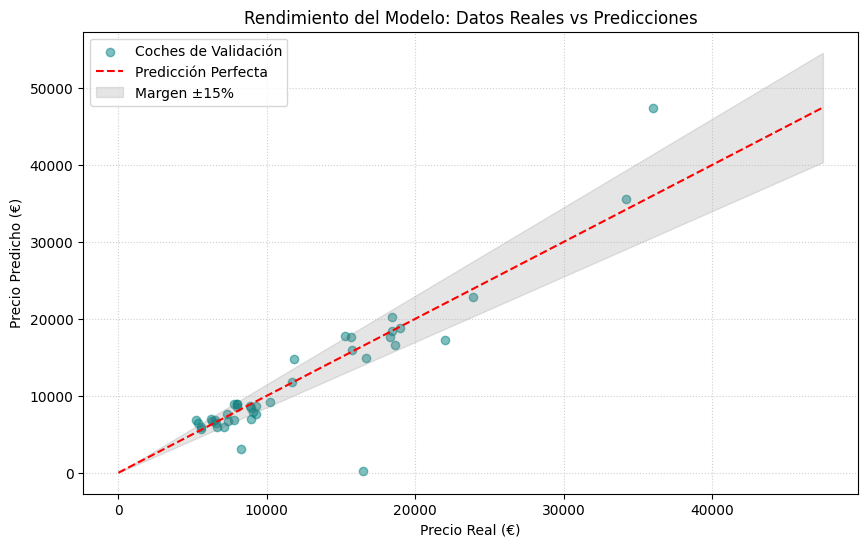

In [257]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Modo evaluación
model.eval()

todos_reales = []
todas_predicciones = []

# 2. Iteramos sobre todo el validation_loader para tener más puntos
with torch.no_grad():
    for entradas, reales in validation_loader:
        predicciones = model(entradas.to(device)).cpu().numpy()
        
        todos_reales.extend(reales.numpy())
        todas_predicciones.extend(predicciones)

# Convertir a arrays para graficar
todos_reales = np.array(todos_reales).flatten()
todas_predicciones = np.array(todas_predicciones).flatten()

# 3. Crear la gráfica
plt.figure(figsize=(10, 6))
plt.scatter(todos_reales, todas_predicciones, alpha=0.5, color='teal', label='Coches de Validación')

# Línea de perfección (donde real == predicción)
max_val = max(todos_reales.max(), todas_predicciones.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Predicción Perfecta')

# Margen del 15% sombreado
x_range = np.linspace(0, max_val, 100)
plt.fill_between(x_range, x_range*0.85, x_range*1.15, color='gray', alpha=0.2, label='Margen ±15%')

plt.title('Rendimiento del Modelo: Datos Reales vs Predicciones')
plt.xlabel('Precio Real (€)')
plt.ylabel('Precio Predicho (€)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Guaradar el Modelo (Exportación del state_dict)

In [258]:
# Definimos el nombre de la carpeta y creamos la ruta completa
carpeta_modelos = 'modelos'
ruta_archivo = os.path.join(carpeta_modelos, 'modelo_automobile_entrenado.pth')

os.makedirs(carpeta_modelos, exist_ok=True)

# Guardamos el "cerebro" de la red en esa nueva ruta
torch.save(model.state_dict(), ruta_archivo)

print(f"¡Modelo guardado exitosamente en la ruta: {ruta_archivo}!")

¡Modelo guardado exitosamente en la ruta: modelos\modelo_automobile_entrenado.pth!


### Guardar el escalado

Aparte de guardar el modelo se puede guaradar el escalado con el que se entrenó el dataset. Sirve para nuevas prediciones 

In [259]:
# Definimos nombre carpeta
carpeta_scaler = 'scaler'
ruta_archivo_scaler = os.path.join(carpeta_scaler, 'scaler_auto.bin')
os.makedirs(carpeta_scaler, exist_ok=True)
# Guardamos el scaler (que está dentro de tu clase AutomobileDataset)
joblib.dump(dataset.scaler, ruta_archivo_scaler)
print("¡Scaler guardado correctamente!")

¡Scaler guardado correctamente!


In [260]:
# Cargamos el scaler
# scaler_cargado = joblib.load('scaler/scaler_auto.bin')

## Predicción

### Cargar Modelo entrenado

In [261]:
model.load_state_dict(torch.load('modelos/modelo_automobile_entrenado.pth'))
model.eval() # Modo evaluación (importante para desactivar Dropout/Batchnorm si los hubiera)

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [262]:
import torch

def probar_predicciones(modelo, dataset, num_muestras=5):
    # 1. Ponemos el modelo en modo evaluación
    modelo.eval()
    
    print(f"{'Nº':<5} | {'Precio Real':<15} | {'Predicción':<15} | {'Diferencia (€)':<15}")
    print("-" * 55)

    # 2. Desactivamos el cálculo de gradientes para ahorrar memoria y tiempo
    with torch.no_grad():
        for i in range(num_muestras):
            # Obtenemos una muestra del dataset (ya escalada)
            # dataset[i] devuelve (features, target)
            input_data, precio_real = dataset[i]
            
            # Añadimos la dimensión del batch [1, 67] y enviamos al device
            input_data = input_data.unsqueeze(0).to(device)
            
            # Realizamos la predicción
            prediccion = modelo(input_data)
            
            # Extraemos los valores escalares
            real_val = precio_real.item()
            pred_val = prediccion.item()
            error = abs(real_val - pred_val)

            # Imprimimos resultados formateados
            print(f"{i+1:<5} | {real_val:>12.2f}€ | {pred_val:>12.2f}€ | {error:>12.2f}€")

# Ejecutamos la prueba
probar_predicciones(model, dataset, num_muestras=10)

Nº    | Precio Real     | Predicción      | Diferencia (€) 
-------------------------------------------------------
1     |     13495.00€ |     14849.97€ |      1354.97€
2     |     16500.00€ |     14849.97€ |      1650.03€
3     |     16500.00€ |     16241.86€ |       258.14€
4     |     13950.00€ |     11945.34€ |      2004.66€
5     |     17450.00€ |     17426.60€ |        23.40€
6     |     15250.00€ |     17765.59€ |      2515.59€
7     |     17710.00€ |     19105.89€ |      1395.89€
8     |     18920.00€ |     18884.34€ |        35.66€
9     |     23875.00€ |     22803.44€ |      1071.56€
10    |     16430.00€ |     17570.08€ |      1140.08€
